<a href="https://colab.research.google.com/github/Anik-Paul-toj/Car-Price/blob/main/CarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Install dependencies
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# File inside the dataset
file_path = "car data.csv"

# Load dataset
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nehalbirla/vehicle-dataset-from-cardekho",
    file_path,
)

print(df.head())

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


In [ ]:
df.shape

(301, 9)

In [ ]:
df.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


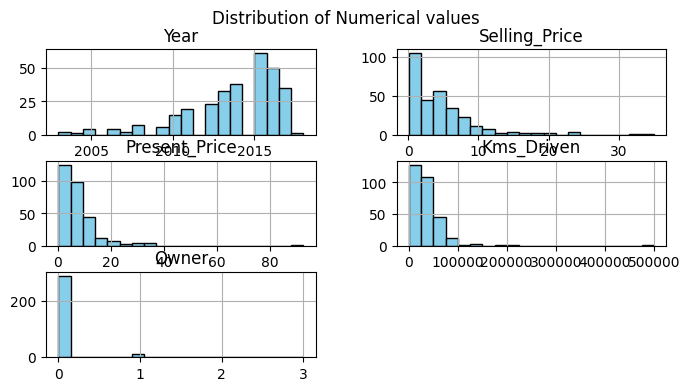

In [ ]:
numeric_cols = ['Year',	'Selling_Price',	'Present_Price',	'Kms_Driven', 'Owner']
df[numeric_cols].hist(bins=20,figsize=(8,4), color = 'skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical values')
plt.show()

In [ ]:
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

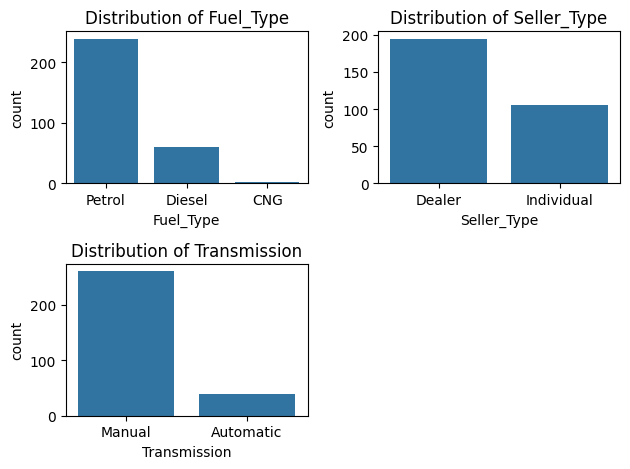

In [ ]:
for i,col in enumerate(categorical_cols,1):
  plt.subplot(2,2,i)
  sns.countplot(data=df, x= col)
  plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby(['Kms_Driven','Owner','Fuel_Type'])['Selling_Price'].mean().round(2)

,,,Selling_Price
Kms_Driven,Owner,Fuel_Type,
500,0,Petrol,0.58
1000,0,Petrol,0.45
1200,0,Petrol,1.45
1300,0,Petrol,0.65
1400,0,Petrol,1.70
...,...,...,...
135154,0,Petrol,1.50
142000,3,Petrol,2.50
197176,0,Diesel,3.49


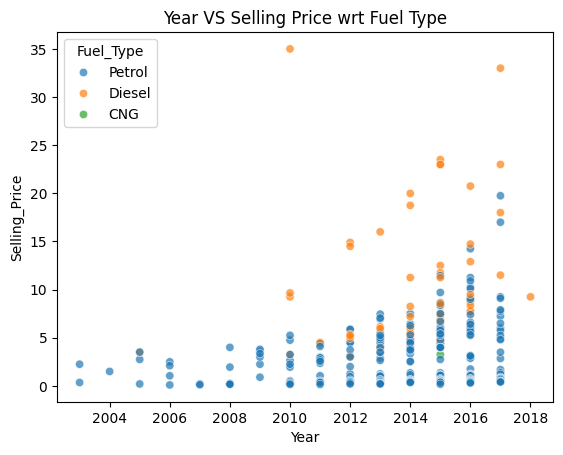

In [ ]:
sns.scatterplot(data=df, x='Year' , y='Selling_Price' ,hue='Fuel_Type', alpha=0.7)
plt.title("Year VS Selling Price wrt Fuel Type")
plt.show()

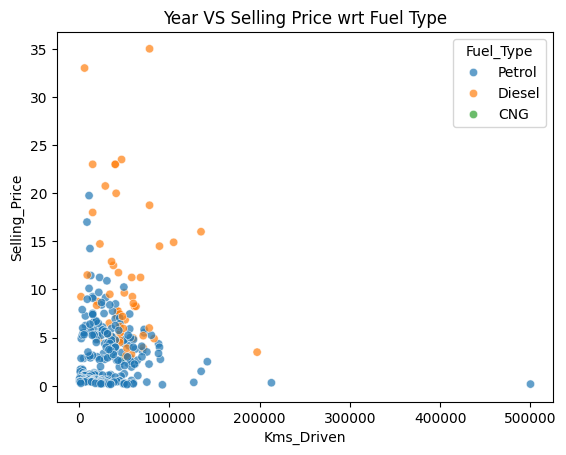

In [ ]:
sns.scatterplot(data=df, x='Kms_Driven' , y='Selling_Price' ,hue='Fuel_Type', alpha=0.7)
plt.title("Year VS Selling Price wrt Fuel Type")
plt.show()

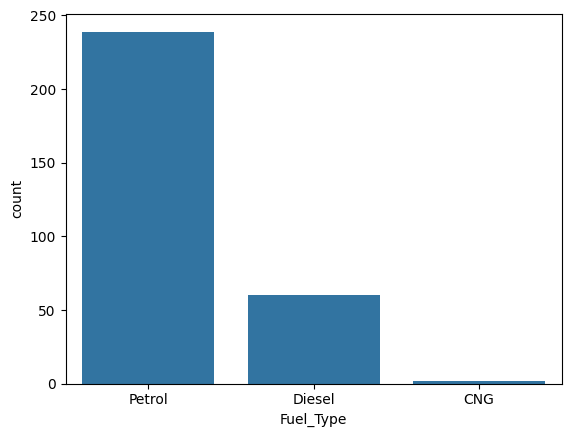

In [ ]:
sns.countplot(data=df, x='Fuel_Type')
plt.show()

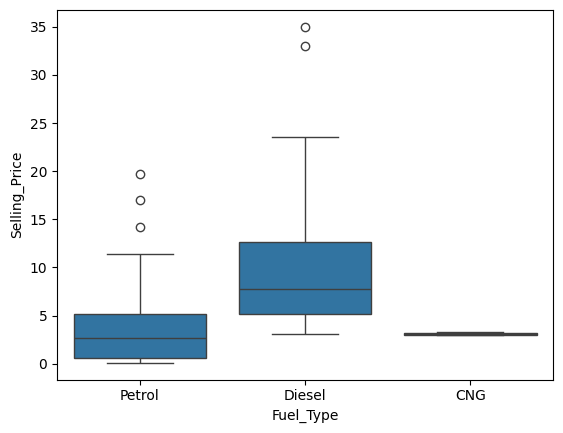

In [ ]:
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.show()

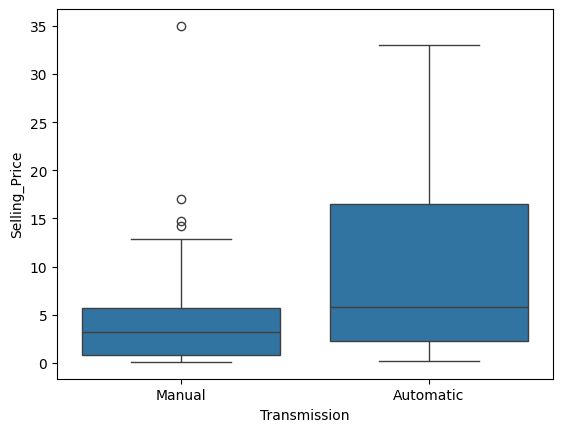

In [ ]:
sns.boxplot(data=df, x='Transmission', y='Selling_Price')
plt.show()

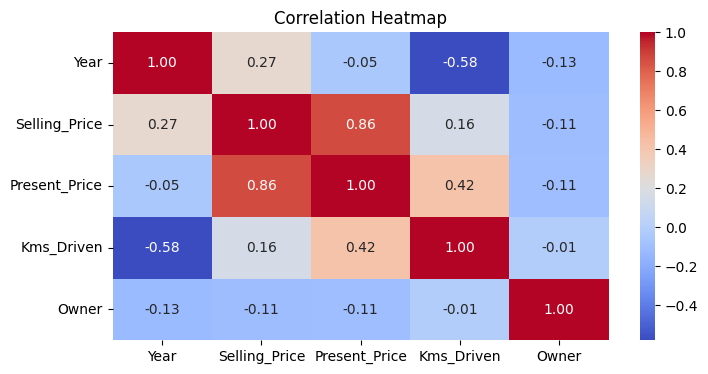

In [ ]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

# Save graph
plt.savefig(
    'graphs/heatmap.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [ ]:
plt.savefig("graphs/heatmap.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

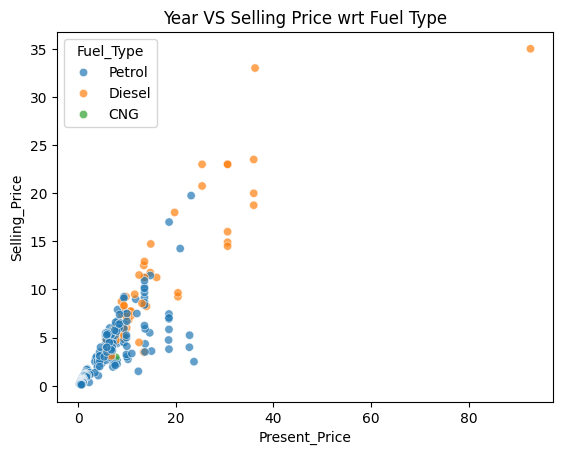

In [ ]:
sns.scatterplot(data=df, x='Present_Price' , y='Selling_Price' ,hue='Fuel_Type', alpha=0.7)
plt.title("Year VS Selling Price wrt Fuel Type")
plt.show()

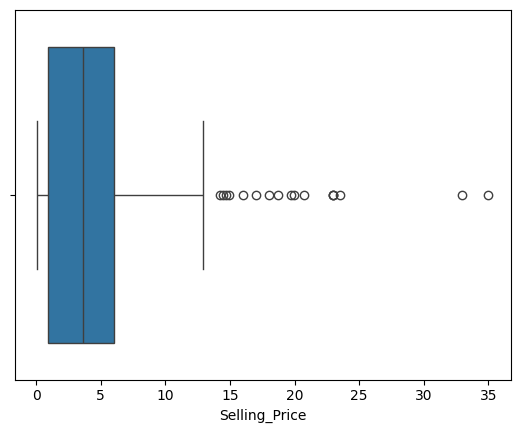

In [ ]:
sns.boxplot(data=df, x='Selling_Price')
plt.show()

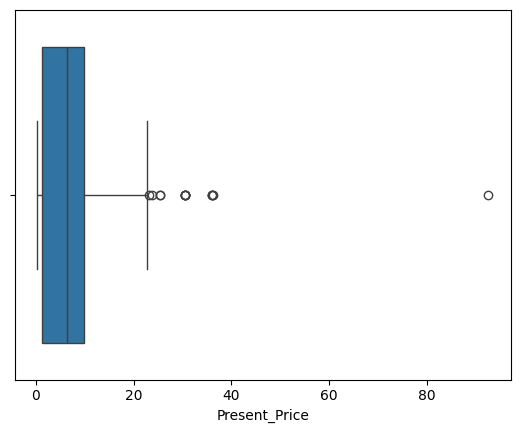

In [ ]:
sns.boxplot(data=df, x='Present_Price')
plt.show()

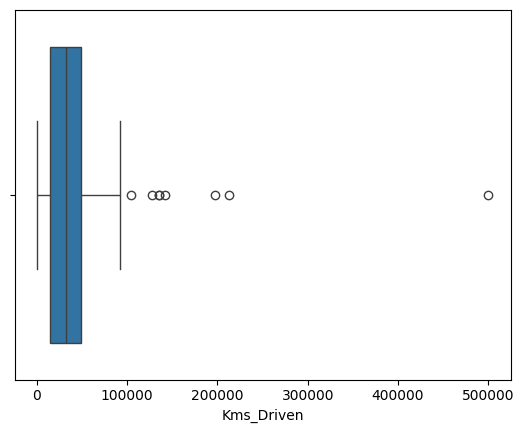

In [ ]:
sns.boxplot(data=df, x='Kms_Driven')
plt.show()

In [ ]:
# For Selling_Price

Q1 = df['Selling_Price'].quantile(0.25)
Q3 = df['Selling_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Selling_Price'] >= lower_limit) &
    (df['Selling_Price'] <= upper_limit)
]

In [ ]:
Q1 = df['Kms_Driven'].quantile(0.25)
Q3 = df['Kms_Driven'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Kms_Driven'] >= lower_limit) &
    (df['Kms_Driven'] <= upper_limit)
]

In [ ]:
Q1 = df['Present_Price'].quantile(0.25)
Q3 = df['Present_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Present_Price'] >= lower_limit) &
    (df['Present_Price'] <= upper_limit)
]

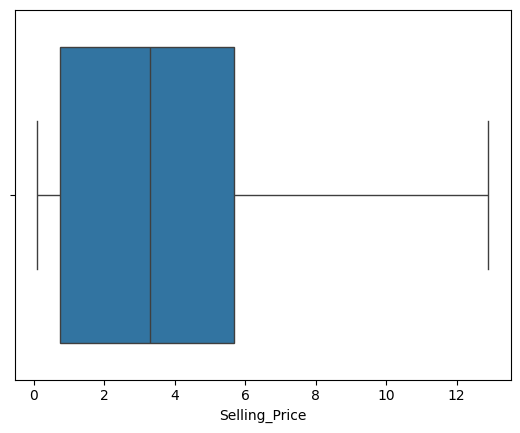

In [ ]:
sns.boxplot(data=df, x='Selling_Price')
plt.show()

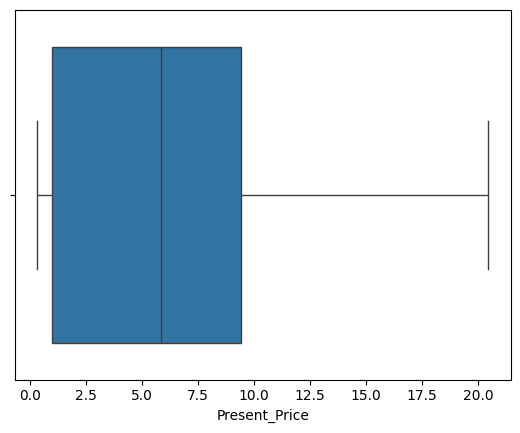

In [ ]:
sns.boxplot(data=df, x='Present_Price')
plt.show()

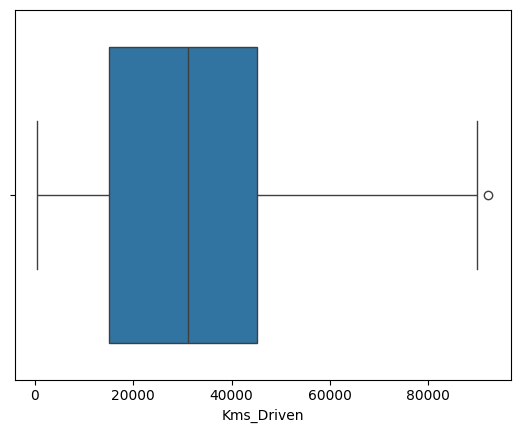

In [ ]:
sns.boxplot(data=df, x='Kms_Driven')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
X = df[['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']]
y = df['Selling_Price']

In [ ]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
num_cols = ['Year', 'Present_Price', 'Kms_Driven', 'Owner']

In [ ]:
lable_encoders = {}

In [ ]:
for i in cat_cols:
  le = LabelEncoder()
  X[i] = le.fit_transform(X[i])
  lable_encoders[i] = le
  joblib.dump(le, f'lable_encoder_{i}.pkl')

/tmp/ipykernel_4457/1060469046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i] = le.fit_transform(X[i])
/tmp/ipykernel_4457/1060469046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i] = le.fit_transform(X[i])
/tmp/ipykernel_4457/1060469046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

In [ ]:
lable_encoders

{'Fuel_Type': LabelEncoder(),
 'Seller_Type': LabelEncoder(),
 'Transmission': LabelEncoder()}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
sc = StandardScaler()
X_train[num_cols] = sc.fit_transform(X_train[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])

In [ ]:
joblib.dump(sc, "standard_scaler.joblib")

['standard_scaler.joblib']

In [ ]:
print(X_train.shape)
print(X_test.shape)
print("========")
print(y_train.shape)
print(y_test.shape)

(220, 7)
(56, 7)
(220,)
(56,)


In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    y_pred_train = model.predict(X_train)   # prediction on training data
    y_pred_test = model.predict(X_test)     # prediction on test data

    r2 = r2_score(y_test, y_pred_test)      # R2 score on test set

    mean_abs_error = mean_absolute_error(y_test, y_pred_test)

    root_mean_sqr = np.sqrt(mean_squared_error(y_test, y_pred_test))
    return {
        "R2 Score": r2,
        "Mean Absolute Error": mean_abs_error,
        "Root Mean Squared Error": root_mean_sqr
    }

In [ ]:
result = {}

In [ ]:
# LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
# Store evaluation results inside dictionary
result["Linear Regression"] = evaluate_model(
    lr, X_train, y_train, X_test, y_test
)

print("Linear Regression model trained")
print("===============================")

Linear Regression model trained


In [ ]:
#Polynomial Regression

best_poly_model = None   # Stores best polynomial model
best_poly_score = -np.inf   # Initialize best score with negative infinity

# Try polynomial degrees from 1 to 4
for degree in range(1, 5):

    # Convert normal features into polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    poly_lr = LinearRegression()

    # Train polynomial regression model
    poly_lr.fit(X_train_poly, y_train)

    # Calculate model score on test data
    score = poly_lr.score(X_test_poly, y_test)

    # Save model if current score is best
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

# Extract best polynomial model details
degree, poly_transformer, poly_lr_model = best_poly_model

# Transform data using the best polynomial transformer
X_train_best_poly = poly_transformer.transform(X_train)
X_test_best_poly = poly_transformer.transform(X_test)

# Store evaluation result
result[f"Polynomial Regression (deg = {degree})"] = evaluate_model(
    poly_lr_model,
    X_train_best_poly,
    y_train,
    X_test_best_poly,
    y_test
)

print("Polynomial Regression model trained")
print("===============================")


Polynomial Regression model trained


In [ ]:
# Decision Tree Regressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

# Store evaluation results inside dictionary
result["Decision Tree Regressor"] = evaluate_model(
    dt, X_train, y_train, X_test, y_test
)

print("Decision Tree Regressor model trained")
print("===============================")

Decision Tree Regressor model trained


In [ ]:
# Random Forest Regressor
rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

result["Random Forest"] = evaluate_model(
    best_rf,
    X_train,
    y_train,
    X_test,
    y_test
)

print("Random Forest model trained")

print("Best Random Forest parameters:", rf_grid.best_params_)

print("===============================")

Random Forest model trained
Best Random Forest parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor()

gbr_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]
}

gbr_grid = GridSearchCV(
    gbr,
    gbr_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

gbr_grid.fit(X_train, y_train)

best_gbr = gbr_grid.best_estimator_

result["Gradient Boosting Regressor"] = evaluate_model(
    best_gbr,
    X_train,
    y_train,
    X_test,
    y_test
)

print("Gradient Boosting Regressor model trained")

print("Best Gradient Boosting Regressor parameters:", gbr_grid.best_params_)

print("===============================")

Gradient Boosting Regressor model trained
Best Gradient Boosting Regressor parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
# Support Vector Regressor (SVR)
from sklearn.svm import SVR as SupportVectorRegressor
svr = SupportVectorRegressor()

svr_params = {
    "kernel" : ['linear', 'rbf', 'poly'],
    "C" : [0.1, 1, 10, 100],
    "epsilon" : [0.01, 0.1, 1, 10],
    "degree" : [2,3]
}

svr_grid = GridSearchCV(
    svr,
    svr_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_

result["Support Vector Regressor"] = evaluate_model(
    best_svr,
    X_train,
    y_train,
    X_test,
    y_test
)
print("SVR model trained")

print("Best SVR parameters:", svr_grid.best_params_)

print("===============================")

SVR model trained
Best SVR parameters: {'C': 100, 'degree': 2, 'epsilon': 0.01, 'kernel': 'rbf'}


In [ ]:
# XGBoost Regressor
xgb = XGBRegressor()

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=3,
    scoring="r2",
    verbose=0,
    n_jobs = -1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

result["XGBoost Regressor"] = evaluate_model(
    best_xgb,
    X_train,
    y_train,
    X_test,
    y_test)
print("XGBoost model trained")

print("Best XGBoost parameters:", xgb_grid.best_params_)

print("===============================")

XGBoost model trained
Best XGBoost parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
result

{'Linear Regression': {'R2 Score': 0.8397787052791943,
  'Mean Absolute Error': 0.893422765213254,
  'Root Mean Squared Error': np.float64(1.1771260074917023)},
 'Polynomial Regression (deg = 2)': {'R2 Score': 0.9335420735078841,
  'Mean Absolute Error': 0.5052205430516526,
  'Root Mean Squared Error': np.float64(0.758116991021113)},
 'Decision Tree Regressor': {'R2 Score': 0.8738036172448316,
  'Mean Absolute Error': 0.6164285714285713,
  'Root Mean Squared Error': np.float64(1.0446872395944293)},
 'Random Forest': {'R2 Score': 0.941179638840943,
  'Mean Absolute Error': 0.4380505234249879,
  'Root Mean Squared Error': np.float64(0.7132252010094569)},
 'Gradient Boosting Regressor': {'R2 Score': 0.9589684506670975,
  'Mean Absolute Error': 0.3904140924233007,
  'Root Mean Squared Error': np.float64(0.5956920371063223)},
 'Support Vector Regressor': {'R2 Score': 0.9214067499852483,
  'Mean Absolute Error': 0.5385589583232925,
  'Root Mean Squared Error': np.float64(0.8244331777532865)}

In [ ]:
result_df = pd.DataFrame(result).T.sort_values(by='R2 Score', ascending= False)
result_df

,R2 Score,Mean Absolute Error,Root Mean Squared Error
XGBoost Regressor,0.960511,0.383175,0.584387
Gradient Boosting Regressor,0.958968,0.390414,0.595692
Random Forest,0.941180,0.438051,0.713225
Polynomial Regression (deg = 2),0.933542,0.505221,0.758117
Support Vector Regressor,0.921407,0.538559,0.824433
Decision Tree Regressor,0.873804,0.616429,1.044687
Linear Regression,0.839779,0.893423,1.177126


In [ ]:
sample_data = pd.DataFrame([[
    2014,
    5.59,
    27000,
    2,
    0,
    1,
    0
]], columns=X.columns)

# Scale numerical columns
sample_data[num_cols] = sc.transform(sample_data[num_cols])

# Predict
prediction = best_xgb.predict(sample_data)

print("Predicted Selling Price:", round(prediction[0], 2), "Lakhs")

Predicted Selling Price: 3.66 Lakhs


In [ ]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
X.columns

Index(['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner'],
      dtype='object')

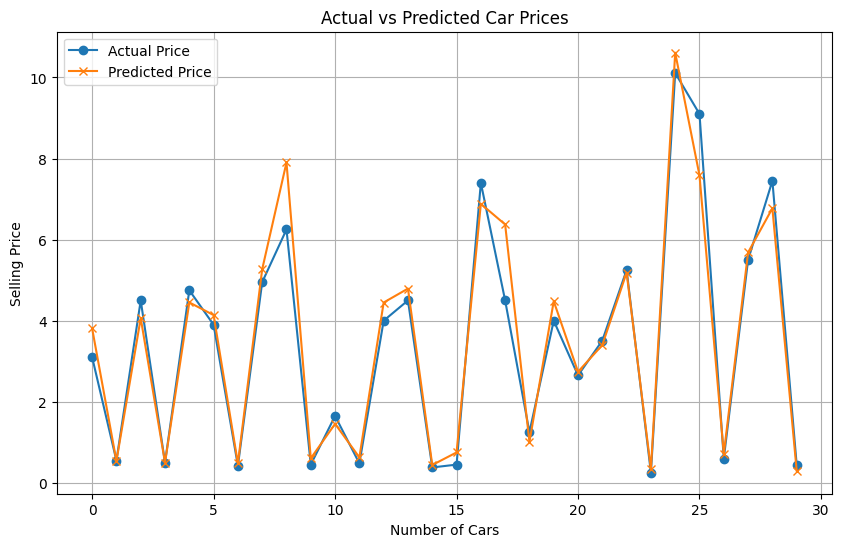

In [ ]:
# Predict using best model
y_pred = best_xgb.predict(X_test)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Plot graph
plt.figure(figsize=(10,6))

plt.plot(
    comparison_df["Actual Price"].values[:30],
    label="Actual Price",
    marker='o'
)

plt.plot(
    comparison_df["Predicted Price"].values[:30],
    label="Predicted Price",
    marker='x'
)

plt.xlabel("Number of Cars")
plt.ylabel("Selling Price")

plt.title("Actual vs Predicted Car Prices")

plt.legend()

plt.grid(True)

# Save graph
plt.savefig(
    'graphs/actual_vs_predicted.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [ ]:
!zip -r graphs.zip graphs

from google.colab import files

files.download("graphs.zip")

updating: graphs/ (stored 0%)
updating: graphs/graph_1.png (deflated 90%)
  adding: graphs/heatmap.png (deflated 12%)
  adding: graphs/actual_vs_predicted.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>